# Max Speed Interval Finding

Identify intervals where players are genuinely skating at max effort, using event context and proximity to derive a reliable signal for a stamina metric.

**Hypothesis:**
- A skater *chasing* a carrier is likely sprinting (max effort)
- A carrier who has *broken away* from defenders is also sprinting
- We tag each tracked player near an event as `carrier`, `chaser`, or `nearby_skater`, then filter to intervals most likely to represent max effort

**Events used:**
| Event | Why |
|---|---|
| Zone Entry (Carried) | Carrier sprinting across blue line; opposing defenders chasing |
| Dump In/Out | Creates a footrace — both teams chasing puck down ice |
| Puck Recovery | Player sprinting to a loose puck |
| Takeaway | Defender closing in on carrier at speed |
| Shot | Shooter driving toward net |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

tracking = pd.read_parquet('../data/tracking.parquet')
events   = pd.read_parquet('../data/events.parquet')

# Consistent game key: date + home @ away
events['Game'] = events['Date'] + ' ' + events['Home_Team'] + ' @ ' + events['Away_Team']

# Normalize tracking Game key (stored as away @ home in image name, flip to home @ away)
tracking_game_raw   = tracking['Image Id'].str.extract(r'(^\d{4}-\d{2}-\d{2}.*?)_')[0]
tracking_game_parts = tracking_game_raw.str.extract(r'^(\d{4}-\d{2}-\d{2})\s+(.*?)\s+@\s+(.*)$')
tracking['Game'] = tracking_game_parts[0] + ' ' + tracking_game_parts[2] + ' @ ' + tracking_game_parts[1]

# Numeric period and countdown seconds (game clock is MM:SS countdown within period)
events['Period_int']   = pd.to_numeric(events['Period'],  errors='coerce')
tracking['Period_int'] = pd.to_numeric(tracking['Period'], errors='coerce')

def clock_to_countdown(clock_str):
    """Convert MM:SS string to integer seconds remaining in period."""
    try:
        m, s = clock_str.split(':')
        return int(m) * 60 + int(s)
    except Exception:
        return np.nan

events['Clock_s']   = events['Clock'].apply(clock_to_countdown)
tracking['Clock_s'] = tracking['Game Clock'].apply(clock_to_countdown)

# Also compute elapsed game seconds (for consistent ordering across periods)
# Period 1: 0-1200, Period 2: 1200-2400, Period 3: 2400-3600, OT: 3600+
def elapsed_seconds(period, clock_s):
    if pd.isna(period) or pd.isna(clock_s):
        return np.nan
    return (period - 1) * 1200 + (1200 - clock_s)

events['Elapsed_s']   = events.apply(lambda r: elapsed_seconds(r['Period_int'], r['Clock_s']), axis=1)
tracking['Elapsed_s'] = tracking.apply(lambda r: elapsed_seconds(r['Period_int'], r['Clock_s']), axis=1)

print('Events shape:  ', events.shape)
print('Tracking shape:', tracking.shape)
print('\nEvent types:\n', events['Event'].value_counts().to_string())

Events shape:   (19200, 25)
Tracking shape: (8401602, 22)

Event types:
 Event
Play               6580
Puck Recovery      5360
Incomplete Play    1783
Zone Entry         1507
Dump In/Out        1476
Shot               1132
Takeaway            631
Faceoff Win         578
Penalty Taken        95
Goal                 58


## Step 1 — Select high-effort event scenarios

Filter to events that tend to generate genuine max-effort skating.

In [2]:
# --- Event scenario definitions ---
# Each scenario specifies:
#   event_type   - which Event value to match
#   detail_filter - optional dict {column: value} to narrow by Detail_1 etc.
#   window_before_s - seconds of tracking to look at BEFORE the event (the approach)
#   window_after_s  - seconds of tracking to look at AFTER the event (the burst)
#   carrier_role    - label for the primary player (Player_Id)
#   chaser_role     - label for opponents/teammates closing in
#   proximity_ft    - max feet from event coordinate a player must be to be counted

SCENARIOS = [
    {
        'label': 'Carried Zone Entry — Carrier',
        'event': 'Zone Entry',
        'detail_filter': ('Detail_1', 'Carried'),
        'role_column': 'carrier',   # Player_Id is the carrier
        'window_before_s': 3,
        'window_after_s': 1,
        'proximity_ft': 60,         # carrier starts from behind blue line (~60 ft back)
    },
    {
        'label': 'Carried Zone Entry — Chaser',
        'event': 'Zone Entry',
        'detail_filter': ('Detail_1', 'Carried'),
        'role_column': 'chaser',    # opposing team players near the carrier
        'window_before_s': 3,
        'window_after_s': 1,
        'proximity_ft': 50,
    },
    {
        'label': 'Dump In/Out — Chaser',
        'event': 'Dump In/Out',
        'detail_filter': None,
        'role_column': 'chaser',    # all nearby skaters are chasing the dumped puck
        'window_before_s': 1,
        'window_after_s': 3,        # chase starts AFTER the dump
        'proximity_ft': 80,         # puck travels far so wider radius
    },
    {
        'label': 'Puck Recovery — Retriever',
        'event': 'Puck Recovery',
        'detail_filter': None,
        'role_column': 'carrier',   # recovering player was sprinting to get there
        'window_before_s': 3,
        'window_after_s': 0,
        'proximity_ft': 40,
    },
    {
        'label': 'Takeaway — Defender',
        'event': 'Takeaway',
        'detail_filter': None,
        'role_column': 'carrier',   # the defender closing in
        'window_before_s': 3,
        'window_after_s': 0,
        'proximity_ft': 35,
    },
    {
        'label': 'Shot — Shooter',
        'event': 'Shot',
        'detail_filter': None,
        'role_column': 'carrier',   # shooter driving to position
        'window_before_s': 3,
        'window_after_s': 0,
        'proximity_ft': 50,
    },
]

# Keep only skaters (not puck rows) and rows with valid speed
skaters = tracking[
    (tracking['Player or Puck'] == 'Player') &
    tracking['speed_mph_savgol'].notna()
].copy()

print(f'Skater rows with speed: {len(skaters):,}')
print(f'Speed range: {skaters["speed_mph_savgol"].min():.1f} – {skaters["speed_mph_savgol"].max():.1f} mph')
print(f'\nScenarios defined: {len(SCENARIOS)}')

Skater rows with speed: 7,433,415
Speed range: 0.0 – 30.0 mph

Scenarios defined: 6


## Step 2 — Build pre-indexed lookup structures

Pre-group tracking by game+period for fast windowed lookups.

In [5]:
# Group skater tracking by (Game, Period_int) so we can quickly slice by elapsed time
# Store as dict: (game, period) -> DataFrame sorted by Elapsed_s
print('Indexing tracking data by game + period...')
tracking_index = {}
for (game, period), grp in skaters.groupby(['Game', 'Period_int']):
    tracking_index[(game, period)] = grp.sort_values('Elapsed_s')

print(f'Indexed {len(tracking_index)} game-period combinations')

# Rename rink coordinate columns for clarity
X_COL = 'x'
Y_COL = 'y'

def get_tracking_window(game, period, event_elapsed_s, before_s, after_s):
    """Return skater tracking rows within [event_elapsed_s - before_s, + after_s]."""
    key = (game, period)
    if key not in tracking_index:
        return pd.DataFrame()
    grp = tracking_index[key]
    lo = event_elapsed_s - before_s
    hi = event_elapsed_s + after_s
    return grp[(grp['Elapsed_s'] >= lo) & (grp['Elapsed_s'] <= hi)]

# Quick sanity check
sample_game = list(tracking_index.keys())[0]
window = get_tracking_window(sample_game[0], sample_game[1], 300, 3, 1)
print(f'\nSample window for {sample_game}: {len(window)} rows')

Indexing tracking data by game + period...
Indexed 30 game-period combinations

Sample window for ('2025-10-11 Team D @ Team A', 1.0): 1627 rows


## Step 3 — Extract high-effort intervals

For each event in each scenario, find all skaters within the proximity radius during the time window, compute their distance from the event, and record their speed.

In [6]:
records = []

for scenario in SCENARIOS:
    evt_type       = scenario['event']
    detail_filter  = scenario['detail_filter']
    role_col       = scenario['role_column']
    before_s       = scenario['window_before_s']
    after_s        = scenario['window_after_s']
    prox_ft        = scenario['proximity_ft']
    label          = scenario['label']

    # Filter to matching events
    mask = events['Event'] == evt_type
    if detail_filter:
        col, val = detail_filter
        mask &= events[col] == val
    evts = events[mask].copy()

    print(f'{label}: {len(evts)} events...')
    
    for _, evt in evts.iterrows():
        game      = evt['Game']
        period    = evt['Period_int']
        elapsed   = evt['Elapsed_s']
        ex, ey    = evt['X_Coordinate'], evt['Y_Coordinate']
        primary_player = str(evt['Player_Id']) if pd.notna(evt['Player_Id']) else None
        primary_team   = evt['Team']

        if pd.isna(elapsed) or pd.isna(ex) or pd.isna(ey) or pd.isna(period):
            continue

        window = get_tracking_window(game, period, elapsed, before_s, after_s)
        if window.empty:
            continue

        # Compute distance from event for each player frame
        dx = window[X_COL] - ex
        dy = window[Y_COL] - ey
        dist = np.sqrt(dx**2 + dy**2)
        window = window.copy()
        window['dist_from_event_ft'] = dist

        # Filter to players within proximity radius
        nearby = window[window['dist_from_event_ft'] <= prox_ft]
        if nearby.empty:
            continue

        # Determine role for each player in this window
        for jersey, player_grp in nearby.groupby('Player Jersey Number'):
            jersey_str = str(jersey)
            player_team = player_grp['Team'].iloc[0]

            if role_col == 'carrier':
                # Only include the primary player (Player_Id)
                if jersey_str != primary_player:
                    continue
                role = 'carrier'
            else:
                # role_col == 'chaser': include opponents of the primary team
                if player_team == primary_team:
                    continue  # Skip same-team players for chaser role
                role = 'chaser'

            speeds = player_grp['speed_mph_savgol'].dropna()
            if speeds.empty:
                continue

            records.append({
                'Scenario':           label,
                'Game':               game,
                'Period':             int(period),
                'Event_Elapsed_s':    elapsed,
                'Event_Clock':        evt['Clock'],
                'Player_Jersey':      jersey_str,
                'Team':               player_team,
                'Role':               role,
                'Mean_Dist_ft':       player_grp['dist_from_event_ft'].mean(),
                'Min_Dist_ft':        player_grp['dist_from_event_ft'].min(),
                'Max_Speed_mph':      speeds.max(),
                'Mean_Speed_mph':     speeds.mean(),
                'Frame_Count':        len(speeds),
                'Primary_Player':     primary_player,
                'Is_Primary':         jersey_str == primary_player,
            })

effort_df = pd.DataFrame(records)
print(f'\nTotal high-effort intervals captured: {len(effort_df)}')
print(f'Unique player-events: {len(effort_df)}')
print('\nBreakdown by scenario:')
print(effort_df.groupby('Scenario')[['Max_Speed_mph', 'Mean_Dist_ft']].agg({'Max_Speed_mph': ['count', 'mean', 'median'], 'Mean_Dist_ft': 'mean'}).round(2).to_string())

Carried Zone Entry — Carrier: 745 events...
Carried Zone Entry — Chaser: 745 events...
Dump In/Out — Chaser: 1476 events...
Puck Recovery — Retriever: 5360 events...
Takeaway — Defender: 631 events...
Shot — Shooter: 1132 events...

Total high-effort intervals captured: 24036
Unique player-events: 24036

Breakdown by scenario:
                             Max_Speed_mph               Mean_Dist_ft
                                     count   mean median         mean
Scenario                                                             
Carried Zone Entry — Carrier           619  20.35  20.64        25.94
Carried Zone Entry — Chaser           4609  18.12  18.06        30.31
Dump In/Out — Chaser                 12851  16.26  16.50        38.55
Puck Recovery — Retriever             4469  15.84  16.11        14.34
Shot — Shooter                         960  15.51  15.04        15.96
Takeaway — Defender                    528  15.94  15.88        13.83


## Step 4 — Validate: speed distribution by scenario and role

Check whether the scenarios are actually capturing high-effort skating vs baseline.

Overall tracking speed — mean: 9.0 mph, 95th pct: 17.3 mph
High-effort intervals — mean max speed: 16.6 mph



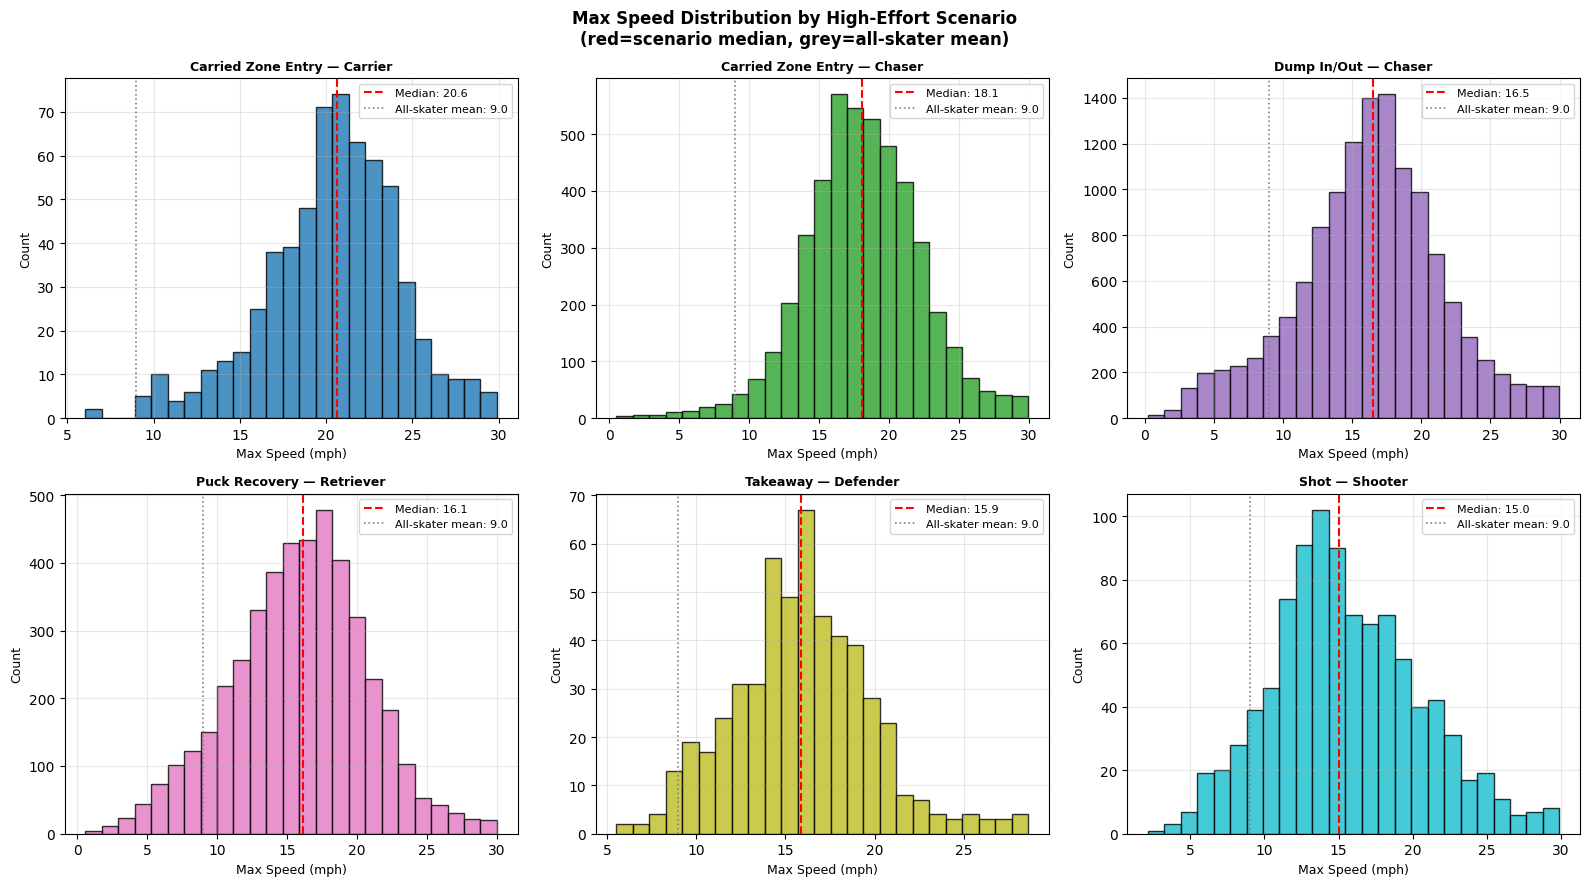

In [7]:
# Overall speed baseline from all tracked skaters
baseline_max_speed = skaters['speed_mph_savgol'].quantile(0.95)
overall_mean       = skaters['speed_mph_savgol'].mean()

print(f'Overall tracking speed — mean: {overall_mean:.1f} mph, 95th pct: {baseline_max_speed:.1f} mph')
print(f'High-effort intervals — mean max speed: {effort_df["Max_Speed_mph"].mean():.1f} mph\n')

# Distribution of max speed by scenario
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

scenarios_in_data = effort_df['Scenario'].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(scenarios_in_data)))

for i, (sc, col) in enumerate(zip(scenarios_in_data, colors)):
    ax = axes[i]
    speeds = effort_df[effort_df['Scenario'] == sc]['Max_Speed_mph']
    ax.hist(speeds, bins=25, color=col, edgecolor='black', alpha=0.8)
    ax.axvline(speeds.median(), color='red', linestyle='--', linewidth=1.5,
               label=f'Median: {speeds.median():.1f}')
    ax.axvline(overall_mean, color='grey', linestyle=':', linewidth=1.2,
               label=f'All-skater mean: {overall_mean:.1f}')
    ax.set_title(sc, fontsize=9, fontweight='bold', wrap=True)
    ax.set_xlabel('Max Speed (mph)', fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

# Hide unused subplot
if len(scenarios_in_data) < len(axes):
    for j in range(len(scenarios_in_data), len(axes)):
        axes[j].set_visible(False)

plt.suptitle('Max Speed Distribution by High-Effort Scenario\n(red=scenario median, grey=all-skater mean)', 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

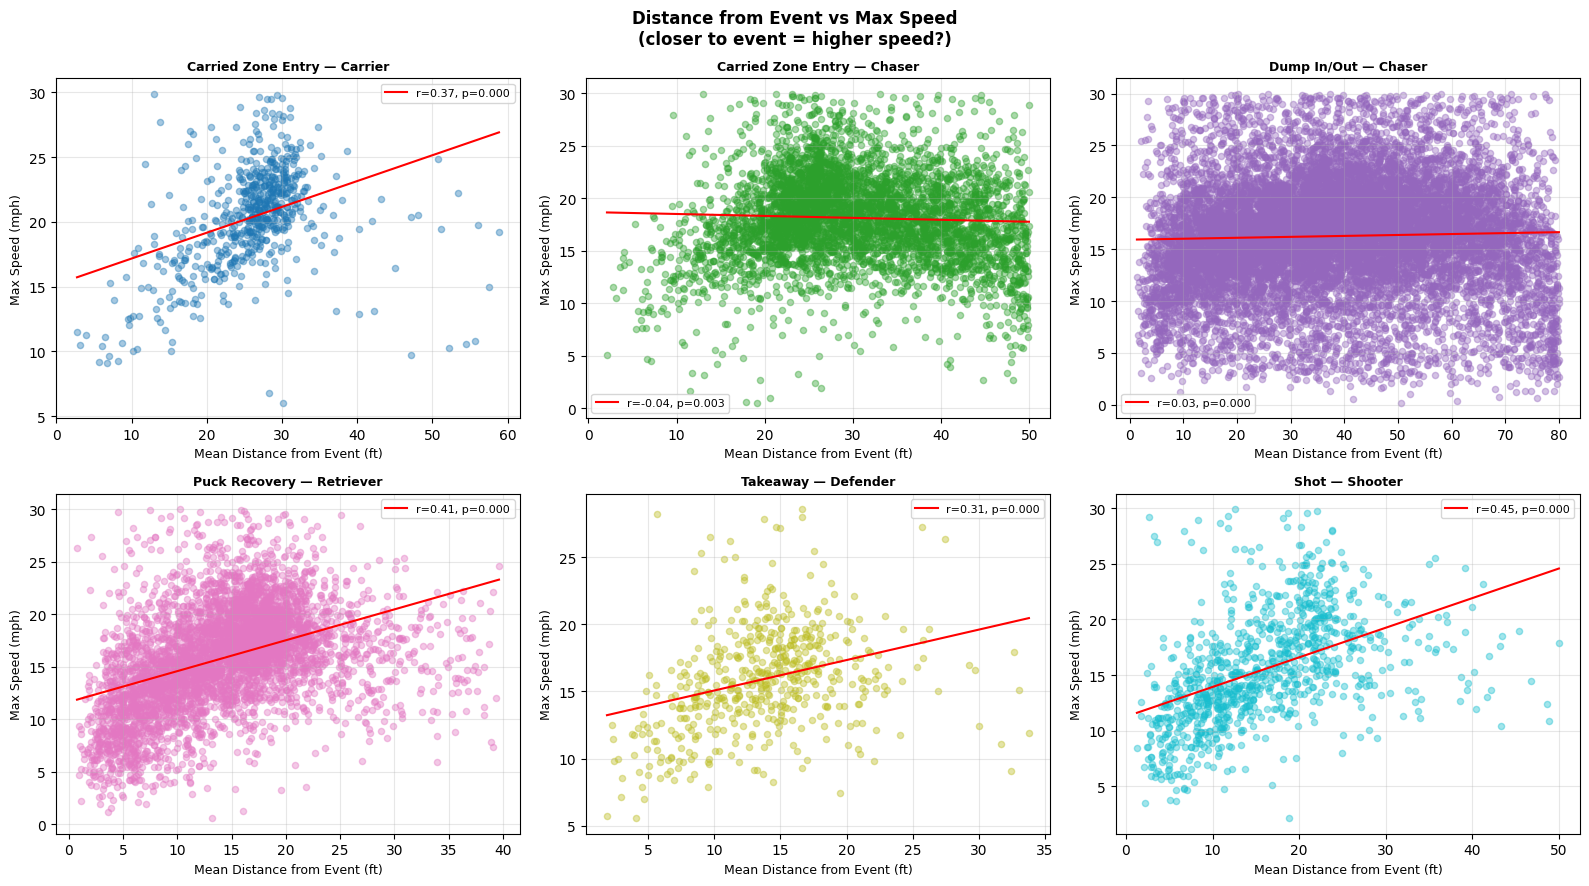

In [8]:
# Speed vs distance from event — does being closer mean faster?
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, (sc, col) in enumerate(zip(scenarios_in_data, colors)):
    ax = axes[i]
    sub = effort_df[effort_df['Scenario'] == sc]
    ax.scatter(sub['Mean_Dist_ft'], sub['Max_Speed_mph'], alpha=0.4, s=20, color=col)
    
    # Regression line
    if len(sub) >= 10:
        slope, intercept, r, p, _ = stats.linregress(sub['Mean_Dist_ft'], sub['Max_Speed_mph'])
        x_line = np.linspace(sub['Mean_Dist_ft'].min(), sub['Mean_Dist_ft'].max(), 100)
        ax.plot(x_line, slope * x_line + intercept, color='red', linewidth=1.5,
                label=f'r={r:.2f}, p={p:.3f}')
        ax.legend(fontsize=8)

    ax.set_title(sc, fontsize=9, fontweight='bold')
    ax.set_xlabel('Mean Distance from Event (ft)', fontsize=9)
    ax.set_ylabel('Max Speed (mph)', fontsize=9)
    ax.grid(alpha=0.3)

if len(scenarios_in_data) < len(axes):
    for j in range(len(scenarios_in_data), len(axes)):
        axes[j].set_visible(False)

plt.suptitle('Distance from Event vs Max Speed\n(closer to event = higher speed?)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 5 — Stamina metric from high-effort max speeds

For each player × game, collect their max speeds at each high-effort interval and fit a linear slope across elapsed game time. A negative slope = speed declining over the game = fatigue signal.

In [9]:
# Compute per-player per-game slope of max speeds across elapsed game time
# Use all scenarios combined — we want the richest possible picture of max efforts

stamina_records = []

for (game, player), grp in effort_df.groupby(['Game', 'Player_Jersey']):
    grp = grp.sort_values('Event_Elapsed_s')
    
    # Need at least 4 observations for a meaningful slope
    if len(grp) < 4:
        continue
    
    x = grp['Event_Elapsed_s'].values
    y = grp['Max_Speed_mph'].values
    
    slope, intercept, r, p_val, se = stats.linregress(x, y)
    
    # Also compute per-period mean max speed
    period_means = grp.groupby('Period')['Max_Speed_mph'].mean().to_dict()
    
    stamina_records.append({
        'Game':              game,
        'Player_Jersey':     player,
        'Team':              grp['Team'].iloc[0],
        'N_Efforts':         len(grp),
        'Periods_Observed':  grp['Period'].nunique(),
        'Peak_Speed_mph':    y.max(),
        'Mean_Max_Speed':    y.mean(),
        'Speed_Slope':       slope,      # mph per second of game time (negative = declining)
        'Speed_Slope_per_min': slope * 60, # mph per minute (easier to interpret)
        'R_squared':         r**2,
        'P_value':           p_val,
        'P1_Mean':           period_means.get(1, np.nan),
        'P2_Mean':           period_means.get(2, np.nan),
        'P3_Mean':           period_means.get(3, np.nan),
    })

stamina_df = pd.DataFrame(stamina_records)
print(f'Players with stamina slopes: {len(stamina_df)}')
print(f'(min 4 high-effort intervals required)\n')
print(stamina_df[['Speed_Slope_per_min', 'Peak_Speed_mph', 'Mean_Max_Speed', 'N_Efforts', 'R_squared']].describe().round(3))

Players with stamina slopes: 332
(min 4 high-effort intervals required)

       Speed_Slope_per_min  Peak_Speed_mph  Mean_Max_Speed  N_Efforts  \
count              332.000         332.000         332.000    332.000   
mean                -0.013          27.638          16.771     72.349   
std                  0.045           2.086           1.952     27.744   
min                 -0.183          16.863           6.697     14.000   
25%                 -0.038          26.452          16.062     52.000   
50%                 -0.013          28.210          17.005     69.000   
75%                  0.016          29.317          17.881     88.000   
max                  0.144          29.994          20.598    180.000   

       R_squared  
count    332.000  
mean       0.023  
std        0.035  
min        0.000  
25%        0.003  
50%        0.010  
75%        0.030  
max        0.236  


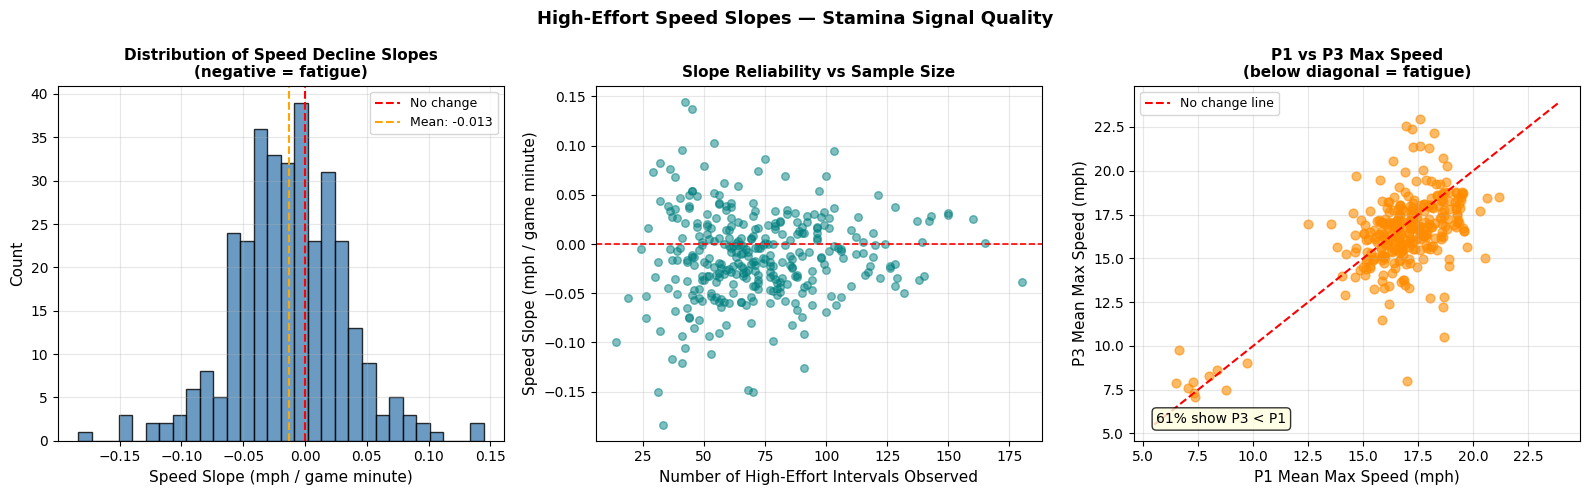

In [10]:
# Visualize: distribution of slopes and best/worst stamina players
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Slope distribution
axes[0].hist(stamina_df['Speed_Slope_per_min'], bins=30, edgecolor='black', alpha=0.8, color='steelblue')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='No change')
axes[0].axvline(stamina_df['Speed_Slope_per_min'].mean(), color='orange', linestyle='--',
                label=f'Mean: {stamina_df["Speed_Slope_per_min"].mean():.3f}')
axes[0].set_xlabel('Speed Slope (mph / game minute)', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_title('Distribution of Speed Decline Slopes\n(negative = fatigue)', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# N_Efforts vs slope — more observations = more reliable
axes[1].scatter(stamina_df['N_Efforts'], stamina_df['Speed_Slope_per_min'], alpha=0.5, s=30, color='teal')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.2)
axes[1].set_xlabel('Number of High-Effort Intervals Observed', fontsize=11)
axes[1].set_ylabel('Speed Slope (mph / game minute)', fontsize=11)
axes[1].set_title('Slope Reliability vs Sample Size', fontsize=11, fontweight='bold')
axes[1].grid(alpha=0.3)

# Period-to-period decline: P1 vs P3 mean max speed
has_p1_p3 = stamina_df.dropna(subset=['P1_Mean', 'P3_Mean'])
axes[2].scatter(has_p1_p3['P1_Mean'], has_p1_p3['P3_Mean'], alpha=0.6, s=40, color='darkorange')
lim_min = min(has_p1_p3['P1_Mean'].min(), has_p1_p3['P3_Mean'].min()) - 1
lim_max = max(has_p1_p3['P1_Mean'].max(), has_p1_p3['P3_Mean'].max()) + 1
axes[2].plot([lim_min, lim_max], [lim_min, lim_max], 'r--', linewidth=1.5, label='No change line')
axes[2].set_xlabel('P1 Mean Max Speed (mph)', fontsize=11)
axes[2].set_ylabel('P3 Mean Max Speed (mph)', fontsize=11)
axes[2].set_title('P1 vs P3 Max Speed\n(below diagonal = fatigue)', fontsize=11, fontweight='bold')
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.3)

pct_below_diag = (has_p1_p3['P3_Mean'] < has_p1_p3['P1_Mean']).mean() * 100
axes[2].text(0.05, 0.05, f'{pct_below_diag:.0f}% show P3 < P1',
             transform=axes[2].transAxes, fontsize=10,
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('High-Effort Speed Slopes — Stamina Signal Quality', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

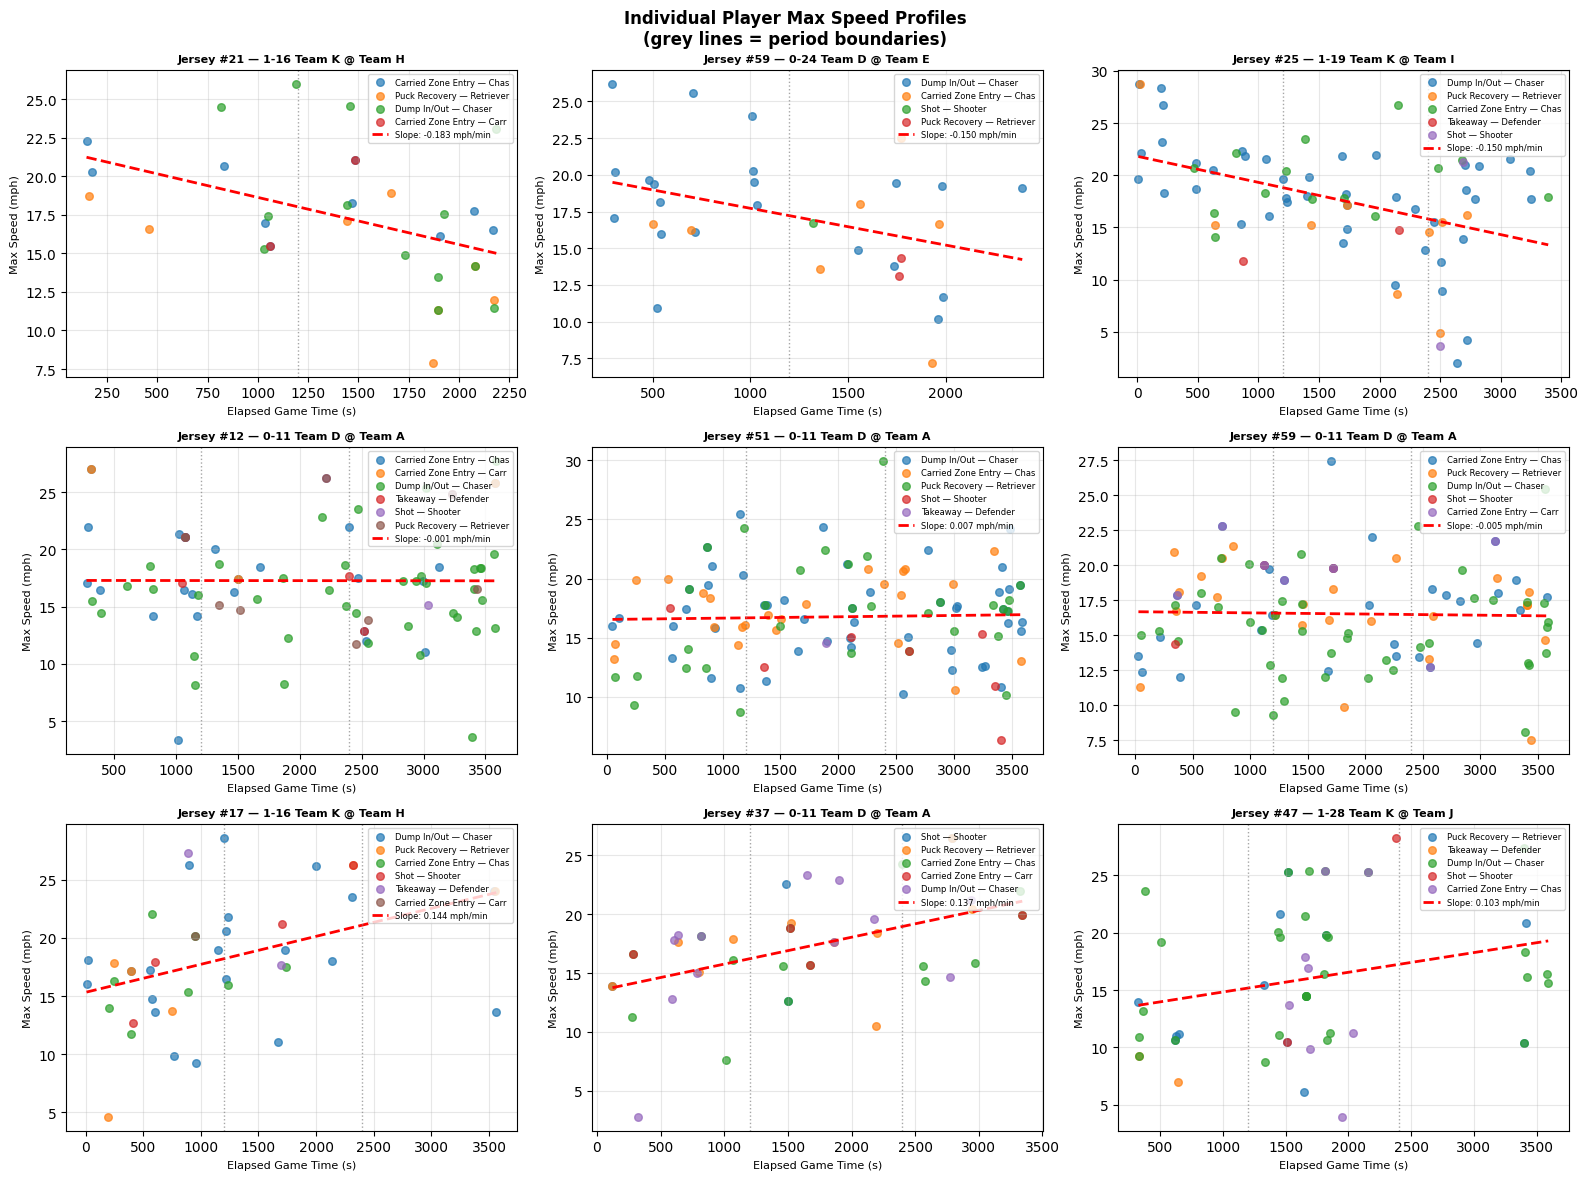

In [11]:
# Sample player profiles: show raw max-speed series over game time
# Pick players with enough observations and a clear slope (either direction)

well_observed = stamina_df[stamina_df['N_Efforts'] >= 8].copy()
declining     = well_observed.nsmallest(3, 'Speed_Slope_per_min')
maintaining   = well_observed[well_observed['Speed_Slope_per_min'].abs() < 0.01].head(3)
improving     = well_observed.nlargest(3, 'Speed_Slope_per_min')
sample_players = pd.concat([declining, maintaining, improving]).drop_duplicates(subset=['Game', 'Player_Jersey'])

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, (_, row) in enumerate(sample_players.iterrows()):
    if i >= 9:
        break
    ax = axes[i]
    grp = effort_df[(effort_df['Game'] == row['Game']) & 
                    (effort_df['Player_Jersey'] == row['Player_Jersey'])].sort_values('Event_Elapsed_s')
    
    x = grp['Event_Elapsed_s'].values
    y = grp['Max_Speed_mph'].values
    
    # Color by scenario
    for sc in grp['Scenario'].unique():
        sc_mask = grp['Scenario'] == sc
        ax.scatter(x[sc_mask.values], y[sc_mask.values], s=30, alpha=0.7, label=sc[:25])
    
    # Trend line
    slope, intercept, r, _, _ = stats.linregress(x, y)
    x_line = np.array([x.min(), x.max()])
    ax.plot(x_line, slope * x_line + intercept, 'r--', linewidth=2,
            label=f'Slope: {slope*60:.3f} mph/min')
    
    # Period markers
    for p in [1200, 2400]:
        if p < x.max():
            ax.axvline(p, color='grey', linestyle=':', linewidth=1, alpha=0.7)
    
    ax.set_title(f'Jersey #{row["Player_Jersey"]} — {row["Game"][-20:]}', fontsize=8, fontweight='bold')
    ax.set_xlabel('Elapsed Game Time (s)', fontsize=8)
    ax.set_ylabel('Max Speed (mph)', fontsize=8)
    ax.legend(fontsize=6, loc='upper right')
    ax.grid(alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Individual Player Max Speed Profiles\n(grey lines = period boundaries)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
# Final summary table
print('=== HIGH-EFFORT INTERVAL STAMINA METRIC ===\n')

print('Top 10 most fatigued players (steepest speed decline):')
cols = ['Game', 'Player_Jersey', 'Team', 'N_Efforts', 'Peak_Speed_mph', 'P1_Mean', 'P3_Mean', 'Speed_Slope_per_min']
print(stamina_df.nsmallest(10, 'Speed_Slope_per_min')[cols].round(2).to_string(index=False))

print('\nTop 10 best-maintained speed (flattest or positive slope):')
print(stamina_df[stamina_df['N_Efforts'] >= 6].nlargest(10, 'Speed_Slope_per_min')[cols].round(2).to_string(index=False))

print('\n--- Summary ---')
pct_declining = (stamina_df['Speed_Slope_per_min'] < 0).mean() * 100
print(f'Players with declining slopes: {pct_declining:.0f}%')
print(f'Mean slope: {stamina_df["Speed_Slope_per_min"].mean():.4f} mph/min')
print(f'Median slope: {stamina_df["Speed_Slope_per_min"].median():.4f} mph/min')
print(f'\nSignificant slopes (p < 0.05): {(stamina_df["P_value"] < 0.05).sum()} / {len(stamina_df)} players')
print('\nNOTE: Speed_Slope_per_min is the primary stamina metric.')
print('More negative = greater fatigue; closer to 0 = better endurance.')

=== HIGH-EFFORT INTERVAL STAMINA METRIC ===

Top 10 most fatigued players (steepest speed decline):
                      Game Player_Jersey Team  N_Efforts  Peak_Speed_mph  P1_Mean  P3_Mean  Speed_Slope_per_min
2025-11-16 Team K @ Team H            21 Away         33           25.98    19.14      NaN                -0.18
2025-10-24 Team D @ Team E            59 Home         31           26.18    18.99      NaN                -0.15
2025-11-19 Team K @ Team I            25 Home         70           28.74    20.53    15.02                -0.15
2025-11-16 Team K @ Team H            25 Home         68           28.09    19.90      NaN                -0.15
2025-11-19 Team K @ Team I            65 Away         91           27.11    18.90    14.54                -0.13
2025-11-16 Team K @ Team H             5 Away         41           27.81    18.87      NaN                -0.12
2025-10-24 Team D @ Team E             2 Away         37           28.11    17.10    13.31                -0.12
2025